# Synthetic Agent Value Profile Analysis

Validates the ValueBench regression pipeline by constructing synthetic agents with known
value priority weights and verifying that the pipeline recovers them. Each synthetic agent
scores choices via a weighted sum of value alignments, makes stochastic decisions through
a sigmoid probability model, and then has its value profile recovered — via logistic
regression followed by softmax(β / T) normalization — using the same pipeline applied to
real LLM/human decision-makers.

In [36]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import load_all_decisions, softmax_profile
from src.analysis.metrics import _get_alignment
from src.analysis.tradeoffs import _fit_logistic_regression
from src.response_models.case import VALUE_NAMES

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"

SEED = 42
rng = np.random.default_rng(SEED)

decisions = load_all_decisions()
print(f"Loaded {len(decisions)} decision records ({len(VALUE_NAMES)} values: {VALUE_NAMES})")

Loaded 51 decision records (4 values: ['autonomy', 'beneficence', 'nonmaleficence', 'justice'])


In [37]:
def compute_synthetic_profile(decisions, weights, n_runs=100, seed=42, temperature=1.0):
    """Simulate a synthetic agent with known value weights and recover its profile.

    For each case the agent scores both choices via a weighted sum of value
    alignments, converts the score difference to P(choice_1) through a sigmoid,
    then draws stochastic runs from a Binomial distribution.  The resulting
    simulated data is fed through the same logistic-regression pipeline used
    for real decision-makers so we can verify that the original weights are
    recoverable.

    Args:
        decisions: List of DecisionRecord objects (only ``record.case`` is used).
        weights: Dict mapping each value name to a priority weight,
            e.g. ``{"autonomy": 0.7, "beneficence": 0.1, ...}``.
        n_runs: Number of simulated Binomial trials per case.
        seed: Random seed for reproducibility.
        temperature: Softmax temperature *T* forwarded to
            :func:`softmax_profile`.  Default ``1.0`` (standard softmax).

    Returns:
        ``(coefficients, profile)`` where *coefficients* is a dict of
        recovered β values and *profile* is the softmax-normalized
        probability distribution over values.
    """
    sim_rng = np.random.default_rng(seed)
    w = np.array([weights[v] for v in VALUE_NAMES], dtype=np.float64)

    X_rows = []
    y_values = []
    n_trials_values = []

    for record in decisions:
        delta = np.array([
            _get_alignment(record.case.choice_1, v)
            - _get_alignment(record.case.choice_2, v)
            for v in VALUE_NAMES
        ], dtype=np.float64)

        score_diff = float(w @ delta)
        p_c1 = float(expit(score_diff))

        c1_count = int(sim_rng.binomial(n_runs, p_c1))

        X_rows.append(delta)
        y_values.append(c1_count / n_runs)
        n_trials_values.append(n_runs)

    X = np.array(X_rows, dtype=np.float64)
    y = np.array(y_values, dtype=np.float64)
    n_trials = np.array(n_trials_values, dtype=np.intp)

    coefficients, _, _, _ = _fit_logistic_regression(X, y, n_trials)
    profile = softmax_profile(coefficients, temperature=temperature)

    return coefficients, profile

In [38]:
PRIORITY_WEIGHT = 0.97
BACKGROUND_WEIGHT = 0.01

SYNTHETIC_AGENTS = {
    name: {v: PRIORITY_WEIGHT if v == name else BACKGROUND_WEIGHT for v in VALUE_NAMES}
    for name in VALUE_NAMES
}

for agent_name, weights in SYNTHETIC_AGENTS.items():
    print(f"{agent_name:>16}: {weights}")

        autonomy: {'autonomy': 0.97, 'beneficence': 0.01, 'nonmaleficence': 0.01, 'justice': 0.01}
     beneficence: {'autonomy': 0.01, 'beneficence': 0.97, 'nonmaleficence': 0.01, 'justice': 0.01}
  nonmaleficence: {'autonomy': 0.01, 'beneficence': 0.01, 'nonmaleficence': 0.97, 'justice': 0.01}
         justice: {'autonomy': 0.01, 'beneficence': 0.01, 'nonmaleficence': 0.01, 'justice': 0.97}


In [39]:
TEMPERATURE = 0.262

rows = []
all_coefficients = {}

for agent_name, weights in SYNTHETIC_AGENTS.items():
    coefficients, profile = compute_synthetic_profile(decisions, weights, n_runs=100, seed=SEED, temperature=TEMPERATURE)
    all_coefficients[agent_name] = coefficients
    for value_name, prob in profile.items():
        rows.append({
            "agent": agent_name.capitalize(),
            "value": value_name.capitalize(),
            "profile_weight": prob,
            "ground_truth": weights[value_name],
        })

results_df = pd.DataFrame(rows)
results_df

,agent,value,profile_weight,ground_truth
0,Autonomy,Autonomy,0.938790,0.97
1,Autonomy,Beneficence,0.022004,0.01
2,Autonomy,Nonmaleficence,0.020372,0.01
3,Autonomy,Justice,0.018834,0.01
4,Beneficence,Autonomy,0.019106,0.01
5,Beneficence,Beneficence,0.944769,0.97
6,Beneficence,Nonmaleficence,0.017414,0.01
7,Beneficence,Justice,0.018711,0.01
8,Nonmaleficence,Autonomy,0.020499,0.01
9,Nonmaleficence,Beneficence,0.018420,0.01


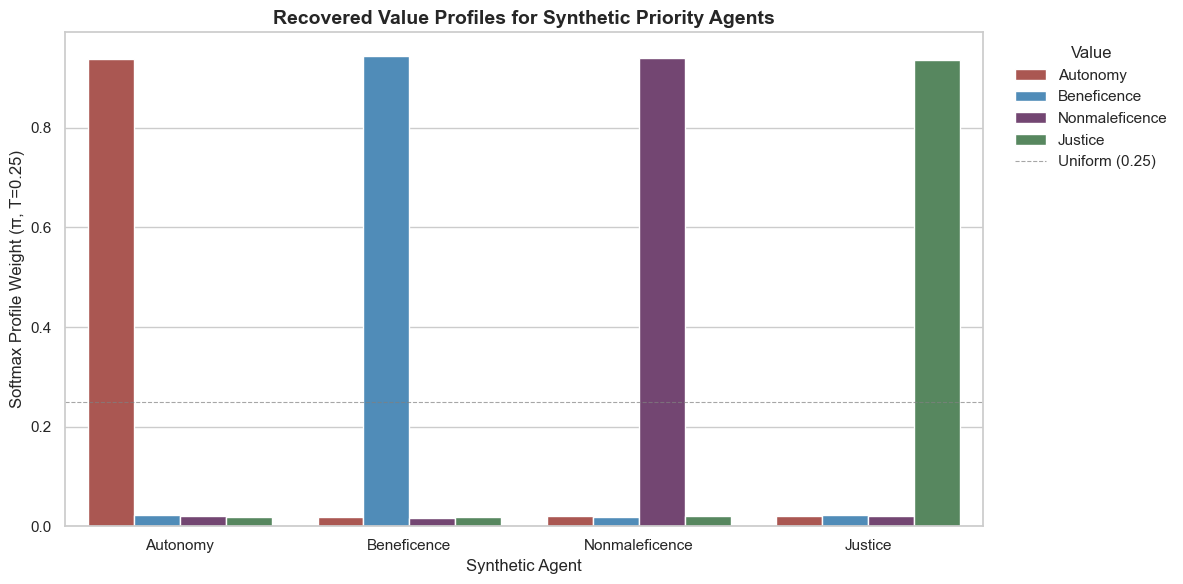

In [40]:
agent_colors = {
    "Autonomy": "#B84A44",
    "Beneficence": "#3F8FC9",
    "Nonmaleficence": "#7A3E7A",
    "Justice": "#4F8F5A",
}

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="agent",
    y="profile_weight",
    hue="value",
    palette=[agent_colors.get(v, "#888888") for v in results_df["value"].unique()],
    ax=ax,
)

ax.axhline(y=0.25, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Uniform (0.25)")
ax.set_xlabel("Synthetic Agent", fontsize=12)
ax.set_ylabel(f"Softmax Profile Weight (π, T={TEMPERATURE})", fontsize=12)
ax.set_title("Recovered Value Profiles for Synthetic Priority Agents", fontsize=14, fontweight="bold")
ax.legend(title="Value", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.tight_layout()
plt.show()

# Temperature Sweep Experiment

Generates many random synthetic agents via a Dirichlet distribution (varying
the concentration parameter $\alpha$ to cover peaked through near-uniform
ground-truth profiles) and sweeps the softmax temperature $T$ to find the
value that best recovers each agent's true distribution.

In [41]:
from scipy.spatial.distance import jensenshannon

ALPHAS = [0.3, 0.5, 1.0, 3.0, 10.0]
AGENTS_PER_ALPHA = 100
N_RUNS = 100

sweep_rng = np.random.default_rng(SEED)

agents: list[dict] = []
for alpha in ALPHAS:
    draws = sweep_rng.dirichlet(np.full(len(VALUE_NAMES), alpha), size=AGENTS_PER_ALPHA)
    for i, w in enumerate(draws):
        agents.append({
            "alpha": alpha,
            "weights": {v: float(w[j]) for j, v in enumerate(VALUE_NAMES)},
        })

print(f"Generated {len(agents)} random agents "
      f"({AGENTS_PER_ALPHA} per α ∈ {ALPHAS})")
print(f"\nExample agent (α=0.3): {agents[0]['weights']}")
print(f"Example agent (α=10): {agents[-1]['weights']}")

Generated 500 random agents (100 per α ∈ [0.3, 0.5, 1.0, 3.0, 10.0])

Example agent (α=0.3): {'autonomy': 0.27284338084979404, 'beneficence': 0.4727841655097849, 'nonmaleficence': 0.00023244730231439454, 'justice': 0.2541400063381066}
Example agent (α=10): {'autonomy': 0.2847406609513936, 'beneficence': 0.2849779091305643, 'nonmaleficence': 0.18552972833422593, 'justice': 0.2447517015838162}


In [42]:
recovered_coefficients: list[dict[str, float]] = []

for idx, agent in enumerate(agents):
    coeffs, _ = compute_synthetic_profile(
        decisions, agent["weights"], n_runs=N_RUNS, seed=SEED + idx, temperature=1.0,
    )
    recovered_coefficients.append(coeffs)

    if (idx + 1) % 100 == 0:
        print(f"  recovered {idx + 1}/{len(agents)} agents")

print(f"\nDone — recovered coefficients for {len(recovered_coefficients)} agents.")

  recovered 100/500 agents
  recovered 200/500 agents
  recovered 300/500 agents
  recovered 400/500 agents
  recovered 500/500 agents

Done — recovered coefficients for 500 agents.


In [43]:
TEMPERATURES = np.logspace(-1.5, 1, 50)

n_agents = len(agents)
n_temps = len(TEMPERATURES)
jsd_matrix = np.empty((n_agents, n_temps))

for j, T in enumerate(TEMPERATURES):
    for i, (agent, coeffs) in enumerate(zip(agents, recovered_coefficients)):
        profile = softmax_profile(coeffs, temperature=T)

        gt = np.array([agent["weights"][v] for v in VALUE_NAMES])
        rec = np.array([profile[v] for v in VALUE_NAMES])

        jsd_matrix[i, j] = jensenshannon(gt, rec) ** 2

alpha_arr = np.array([a["alpha"] for a in agents])

print(f"JSD matrix shape: {jsd_matrix.shape}  "
      f"(agents × temperatures)")
print(f"Temperature range: [{TEMPERATURES[0]:.4f}, {TEMPERATURES[-1]:.4f}]")

JSD matrix shape: (500, 50)  (agents × temperatures)
Temperature range: [0.0316, 10.0000]


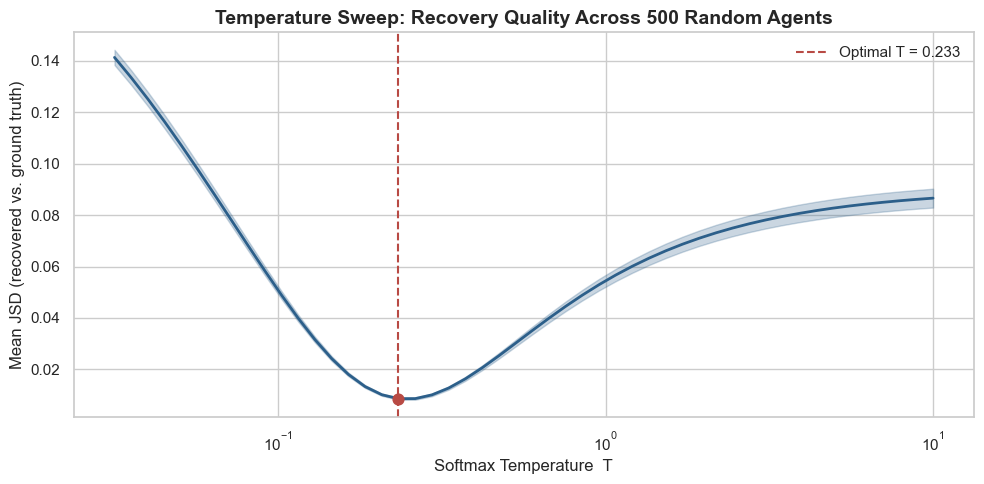

Optimal temperature:  T* = 0.2330
Mean JSD at T*:       0.008570
Std  JSD at T*:       0.008975


In [44]:
mean_jsd = jsd_matrix.mean(axis=0)
std_jsd = jsd_matrix.std(axis=0)
se_jsd = std_jsd / np.sqrt(n_agents)

best_idx = int(np.argmin(mean_jsd))
best_T = TEMPERATURES[best_idx]
best_jsd = mean_jsd[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(TEMPERATURES, mean_jsd, linewidth=2, color="#2C5F8A")
ax.fill_between(TEMPERATURES, mean_jsd - se_jsd, mean_jsd + se_jsd,
                alpha=0.25, color="#2C5F8A")
ax.axvline(best_T, color="#B84A44", linestyle="--", linewidth=1.5,
           label=f"Optimal T = {best_T:.3f}")
ax.scatter([best_T], [best_jsd], color="#B84A44", s=60, zorder=5)

ax.set_xscale("log")
ax.set_xlabel("Softmax Temperature  T", fontsize=12)
ax.set_ylabel("Mean JSD (recovered vs. ground truth)", fontsize=12)
ax.set_title("Temperature Sweep: Recovery Quality Across 500 Random Agents",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

print(f"Optimal temperature:  T* = {best_T:.4f}")
print(f"Mean JSD at T*:       {best_jsd:.6f}")
print(f"Std  JSD at T*:       {std_jsd[best_idx]:.6f}")

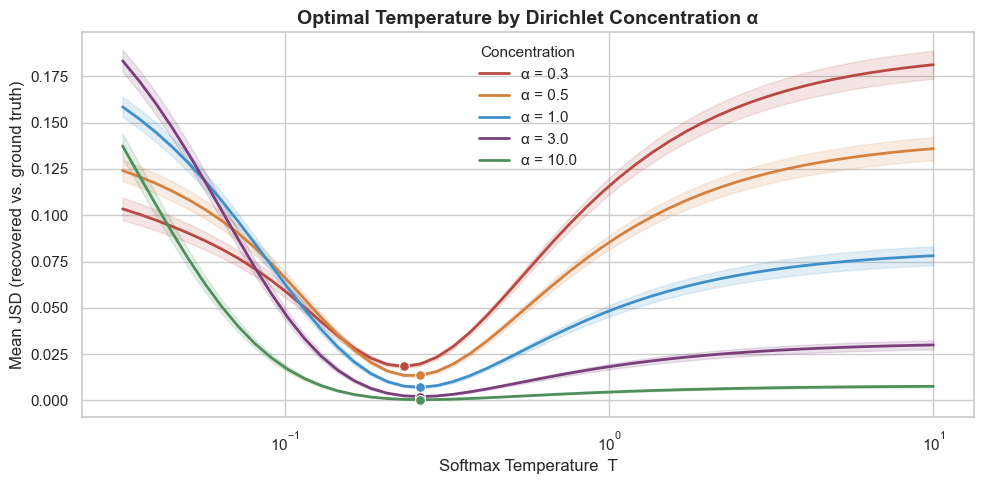

   α Optimal T Mean JSD at T* Std JSD at T*
 0.3    0.2330       0.018372      0.009861
 0.5    0.2620       0.013560      0.008298
 1.0    0.2620       0.007126      0.005524
 3.0    0.2620       0.002124      0.002754
10.0    0.2620       0.000463      0.000481


In [45]:
alpha_palette = {
    0.3:  "#B84A44",
    0.5:  "#D4813F",
    1.0:  "#3F8FC9",
    3.0:  "#7A3E7A",
    10.0: "#4F8F5A",
}

fig, ax = plt.subplots(figsize=(10, 5))

summary_rows = []
for alpha in ALPHAS:
    mask = alpha_arr == alpha
    group_mean = jsd_matrix[mask].mean(axis=0)
    group_se = jsd_matrix[mask].std(axis=0) / np.sqrt(mask.sum())

    ax.plot(TEMPERATURES, group_mean, linewidth=2,
            color=alpha_palette[alpha], label=f"α = {alpha}")
    ax.fill_between(TEMPERATURES, group_mean - group_se, group_mean + group_se,
                    alpha=0.15, color=alpha_palette[alpha])

    opt_idx = int(np.argmin(group_mean))
    opt_T = TEMPERATURES[opt_idx]
    ax.scatter([opt_T], [group_mean[opt_idx]], color=alpha_palette[alpha],
               s=50, zorder=5, edgecolors="white", linewidths=0.8)

    summary_rows.append({
        "α": alpha,
        "Optimal T": f"{opt_T:.4f}",
        "Mean JSD at T*": f"{group_mean[opt_idx]:.6f}",
        "Std JSD at T*": f"{jsd_matrix[mask][:, opt_idx].std():.6f}",
    })

ax.set_xscale("log")
ax.set_xlabel("Softmax Temperature  T", fontsize=12)
ax.set_ylabel("Mean JSD (recovered vs. ground truth)", fontsize=12)
ax.set_title("Optimal Temperature by Dirichlet Concentration α",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11, frameon=False, title="Concentration", title_fontsize=11)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))